# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

In [77]:
# Part 1: your work here

import numpy as np, numpy.linalg as la
import matplotlib.pyplot as plt
from scipy import odr as odrsp
from scipy.optimize import minimize

NETID = 'cmemery2'  # <-- set this
d = np.genfromtxt(f'../../labs/04/data/{NETID}.csv', delimiter=',', names=True)
mst, mstErr, mbh, mbhErr = d['logMstar'],d['err_logMstar'],d['logMBH'],d['err_logMBH']

In [72]:
#ordinary least squares
x = mst - 9.5
y = mbh
xerr = mstErr
yerr = mbhErr
def ols(x, y):
    A = np.array([np.ones_like(x), x]).T
    theta = la.inv(A.T @ A) @ A.T @ y
    res = y - A @ theta
    s2 = res @ res / (len(y) - A.shape[1]) #s^2 = RSS/(N-k) where k=2 for 2 fitted param
    cov = s2 * la.inv(A.T @ A)

    return theta, cov

mbh_hat_ols, alpha_hat_ols = ols(x, y)[0]
mbh_sig_ols, alpha_sig_ols = np.sqrt(np.diag(ols(x, y)[1]))

print('OLS FIT')
print(f"Mbh, beta: {mbh_hat_ols:.3g} +/- {mbh_sig_ols:.3g}")
print(f"Slope, alpha: {alpha_hat_ols:.3g} +/- {alpha_sig_ols:.3g}")

OLS FIT
Mbh, beta: 6.19 +/- 0.0943
Slope, alpha: 0.763 +/- 0.141


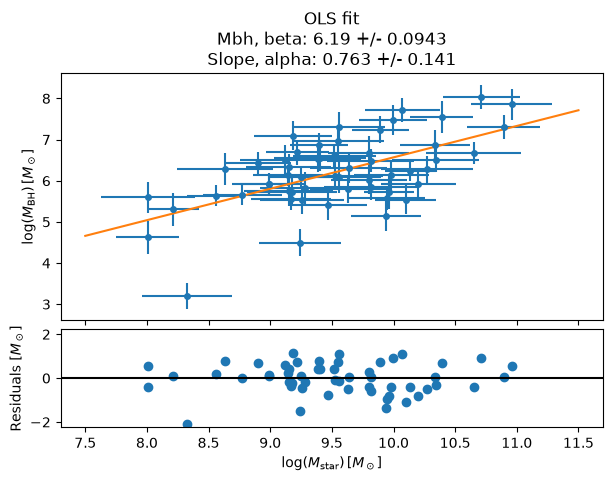

In [64]:
fig, ax = plt.subplots(2, 1, figsize=(7,4.6), sharex=True,
                             gridspec_kw=dict(height_ratios=[3, 1.2], hspace=0.05))
ax[0].errorbar(mst, mbh, xerr=mstErr, yerr=mbhErr, fmt='o', ms=4)
xx = np.linspace(7.5, 11.5, 20)
ax[0].plot(xx, mbh_hat_ols + alpha_hat_ols * (xx-9.5))
ax[1].plot(x+9.5, res, 'o')
ax[1].axhline(0, color='k')
ax[0].set_ylabel(r'$\log(M_{\rm BH}) \, [M_\odot]$')
ax[1].set_ylabel(r'Residuals [$M_\odot$]')
ax[1].set_xlabel(r'$\log(M_{\rm star}) \, [M_\odot]$')
ax[1].set_ylim(-2.25, 2.25)
ax[0].set_title("OLS fit\n"+
            f"Mbh, beta: {mbh_hat_ols:.3g} +/- {mbh_sig_ols:.3g}\n"+
            f"Slope, alpha: {alpha_hat_ols:.3g} +/- {alpha_sig_ols:.3g}")
plt.show()

**ANSWER (a few sentences):**

OLS assumes that x is measured without error, only y has error. Also, it treats all deviation from the fit equallly - it doesn't weight the closest points stronger than it weights further out points. Due to there being error in measured x values, the OLS slope is pulled towards 0 & becomes shallow. The size of the bias has to do with measurement error sigma_x, and is independent of number of data points N.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [81]:
# Part 2: your work here

#WLS
def wls(x, y, yerr):
    A = np.array([np.ones_like(x), x]).T
    Sigma = np.diag(yerr**2)
    theta = la.inv(A.T @ la.inv(Sigma) @ A) @ A.T @ la.inv(Sigma) @ y
    # res = y - A @ theta
    cov = np.linalg.inv(A.T @ la.inv(Sigma) @ A)
    return theta, cov

mbh_hat_wls, alpha_hat_wls = wls(x, y, yerr)[0]
mbh_sig_wls, alpha_sig_wls = np.sqrt(np.diag(wls(x, y, yerr)[1]))

#orthogonal distance regression
def odr(x, y, xerr, yerr):
    def _line(B, x):
        return B[1] * x + B[0]
    _odr = odrsp.ODR(odrsp.RealData(x, y, sx=xerr, sy=yerr), odrsp.Model(_line), 
                beta0=[mbh_hat_ols, alpha_hat_ols])
    odr_out = _odr.run()
    return odr_out.beta, odr_out.sd_beta
mbh_hat_odr, alpha_hat_odr = odr(x, y, xerr, yerr)[0]
mbh_sig_odr, alpha_sig_odr = odr(x, y, xerr, yerr)[1]

#generative model: i copied this from class
# The five-parameter generative fit on the demo sample: bivariate Gaussian per point, curvature error bars (a "skip" cell)
def neg2logL_gen(p, x, y, sx, sy):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2, tau2 = np.exp(2 * log_sint), np.exp(2 * log_sig_pop)
    dx, dy = x - mu, y - (alpha * (mu) + beta) #x = mst - 9.5 already
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    det = s11 * s22 - s12**2
    quad = (s22 * dx**2 - 2 * s12 * dx * dy + s11 * dy**2) / det
    return np.sum(np.log(det) + quad)

def numerical_hessian(f, p, h=1e-4):
    p = np.asarray(p, float); n = p.size; H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n); e_j = np.zeros(n); e_i[i] = h; e_j[j] = h
            H[i, j] = (f(p + e_i + e_j) - f(p + e_i - e_j) - f(p - e_i + e_j) + f(p - e_i - e_j)) / (4 * h * h)
    return H

def gen(x,y,xerr,yerr, alpha_init, beta_init):
    _start = [alpha_init, beta_init, np.log(0.3), x.mean(), np.log(x.std())]
    res_gen = minimize(neg2logL_gen, _start, method='Nelder-Mead', 
                       args=(x, y, xerr, yerr),
                       options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))
    p_gen = res_gen.x
    cov_gen = 2 * np.linalg.inv(numerical_hessian(
        lambda p: neg2logL_gen(p, x, y, xerr, yerr), p_gen)
    )
    return p_gen, cov_gen
# -2lnL curvature -> covariance
p_gen, cov_gen = gen(x,y,xerr,yerr, alpha_hat_ols, mbh_hat_ols)
alpha_gen, mbh_gen, sint_gen, mu_gen, spop_gen = p_gen
sint_gen = np.exp(sint_gen)
spop_gen = np.exp(spop_gen)
alpha_sig_gen, mbh_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_gen))
sint_sig_gen *= sint_gen
spop_sig_gen *= spop_gen

print('OLS FIT')
print(f"Mbh, beta: {mbh_hat_ols:.5g} +/- {mbh_sig_ols:.5g}")
print(f"Slope, alpha: {alpha_hat_ols:.5g} +/- {alpha_sig_ols:.5g}")
print('WLS FIT')
print(f"Mbh, beta: {mbh_hat_wls:.5g} +/- {mbh_sig_wls:.5g}")
print(f"Slope, alpha: {alpha_hat_wls:.5g} +/- {alpha_sig_wls:.5g}")
print('ODR FIT')
print(f"Mbh, beta: {mbh_hat_odr:.5g} +/- {mbh_sig_odr:.5g}")
print(f"Slope, alpha: {alpha_hat_odr:.5g} +/- {alpha_sig_odr:.5g}")
print('GENERATIVE FIT')
print(f"Mbh, beta: {mbh_gen:.5g} +/- {mbh_sig_gen:.5g}")
print(f"Slope, alpha: {alpha_gen:.5g} +/- {alpha_sig_gen:.5g}")
print(f"Intrinsic scatter: {sint_gen:.5g} +/- {sint_sig_gen:.5g}")


OLS FIT
Mbh, beta: 6.1871 +/- 0.094275
Slope, alpha: 0.76315 +/- 0.14085
WLS FIT
Mbh, beta: 6.1958 +/- 0.043203
Slope, alpha: 0.75521 +/- 0.06534
ODR FIT
Mbh, beta: 6.1816 +/- 0.10741
Slope, alpha: 1.344 +/- 0.18482
GENERATIVE FIT
Mbh, beta: 6.1831 +/- 0.093893
Slope, alpha: 0.95164 +/- 0.17594
Intrinsic scatter: 0.53528 +/- 0.086365


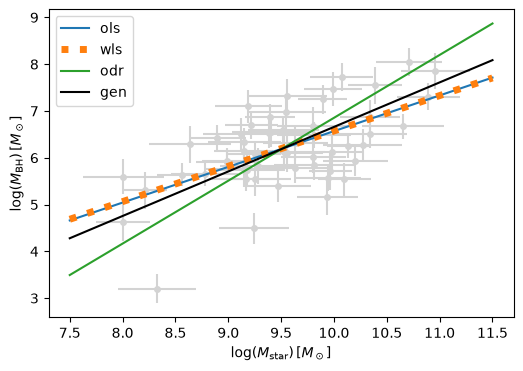

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.errorbar(mst, mbh, xerr=mstErr, yerr=mbhErr, fmt='o', ms=4, zorder=-1, c='lightgray')
xx = np.linspace(7.5, 11.5, 20)
ax.plot(xx, mbh_hat_ols + alpha_hat_ols * (xx-9.5), label='ols')
ax.plot(xx, mbh_hat_wls + alpha_hat_wls * (xx-9.5), label='wls', lw=5, ls='dotted')
ax.plot(xx, mbh_hat_odr + alpha_hat_odr * (xx-9.5), label='odr')
ax.plot(xx, mbh_gen + alpha_gen * (xx-9.5), label='gen', c='k')
ax.legend()
ax.set_ylabel(r'$\log(M_{\rm BH}) \, [M_\odot]$')
ax.set_xlabel(r'$\log(M_{\rm star}) \, [M_\odot]$')
plt.show()

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header:

> your reported $\sigma_\alpha$ may not
> exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
> Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
> than that is not caution, since it's an estimator you should have discarded.

**FINAL ANSWER:** $\alpha = $ 0.96164 $\pm$ 0.17594 (unitless) , $\beta = $ 6.1831 $\pm$ 0.093893 dex , $\sigma_{\rm int} = $ 0.53528 $\pm$ 0.08365 dex

**Justification and uncertainty method (a short paragraph):**

I chose the fitted parameters from the generative fit since it is assuming the same model that i am: the x is drawn from a gaussian population, then the y value is created via the linear relation with some intrinsic scatter, then our observed measurements are these true x, y values + some measurement error. All the other algorithms assume either there is no measurement scatter in x, or there is no intrinsic scatter in the data, and therefore must be biased by either attenuation bias or by outliers.

1. The OLS line is shallow since it doesn't account for attenuation bias due to ignoring sigma_x ie observational error in x. It only wants to minimize residuals. It also ignores that some data points have large error bars and some have smaller errors/more confident measurements, so it treats all points the same. 
2. The WLS line is similarly shallow since it ignores sigma_x and is thus still subject to attenuation bias. However, it doesn't ignore the different errorbars on y, gives higher weight to smaller sigma_y, which is why its reported $\sigma_\alpha$ is more than 1/2 of that of OLS's. It can be more confident when it knows about exact y error values
3. The ODR line is much more steep since it actually knows about & weights with both x and y errors, but it also assumes there is no intrinsic scatter. It thinks all scatter is from measurement error, and there is no additional intrinsic scatter, so when it divides  each residual by $\sqrt{\sigma_y^2 + \alpha^2 \sigma_x^2}$, then the reduced chi^2 gets smaller for overestimated sigma caused by combined intrinsic + measurement errors. this means that the ODR line is biased high,
4. The generative fit assumes that the x is drawn from a gaussian population $\mu$ with scatter $\sigma_{\rm pop}$, then generates a y value using the linear relation & $\sigma_{\rm int}$, then there is also some measurement error for x and y on top of that. So this one assumes the exact same model that we are

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

1. Closure: Using the 5 best fit parameters that my generative fit algorithm produced, i will generate my own observed data. Then, to try to make sure that the gen fit recovers the same values, i will try fitting it to this new data. If the gen fit fails, then the second fit will have values for the 5 param that are outside of each other's sigma. 
2. Bias efficiency: I will perform monte carlo simulations for each method (on the data i made, not the one i was given for this assignment). Failure looks like the distribution of fitted paramers being heavily biased away from the truth values i set
3. Coverage: To make sure all the simulations cover the truth, then 68% of simulations' fitted paramers should contain the true value i set within 1 sigma
4. Sensitivity: I will report to the model that the simulated datasets' x measurement errors are inflated by x.5 and x1.5 to simulate xerrors being incorrect, if gen fit is flawed then it should report very different fitted param here that may sometimes not capture the truth. I'll also try generating populations with uniform distirbution instead of gaussian with same mean/variance, gen fit will probably fail since its assuming that the scatter is gaussian but i can see to what degree will the fitted param change & how much this matters. I'll also try generating populations where sigma_int = 0, and seeing how fitted param change, gen fit might fail to guess its 0.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

In [212]:

#use earlier generative fit alpha, beta, sigma_int, simga_obs, and mu as truth.
alpha_true = alpha_gen
beta_true  = mbh_gen
sig_int    = sint_gen
mu         = mu_gen
sig_pop    = spop_gen

In [109]:
# Part 3b: execute the plan here

# Simulate ~100-1000 fake samples and fit gen to each
Nsamples = 1000 #for now
fits_ols = np.empty((Nsamples, 4)) #(alpha, alpha sigma, beta, beta sigma)
fits_wls = np.empty((Nsamples, 4))
fits_odr = np.empty((Nsamples, 4))
fits_gen = np.empty((Nsamples, 10)) #Param + param's sigma for all 5 fitted param
#Generate data ~100-1000 times:
N = len(x)
for i in range(Nsamples):
    rng = np.random.default_rng(i)

    # generate datasets !!

    #remember: generate ax + b instead of a(x-9.5)+b!!! 
    #earlier gen fit assumed so, so mu is going to be ~0, not ~9.5
    x_true = rng.normal(mu, sig_pop, N)
    y_true = alpha_true * (x_true) + beta_true + rng.normal(0, sig_int, N)
    #bootstrap da errorss
    idx = rng.choice(N, size=N, replace=True)
    xerr_sim = xerr[idx];
    yerr_sim = yerr[idx]
    x_obs = x_true + rng.normal(0, xerr_sim) 
    y_obs = y_true + rng.normal(0, yerr_sim)

    # perform all 4 fits
    ols_out = ols(x_obs, y_obs)
    mbh_hat_ols, alpha_hat_ols = ols_out[0]
    mbh_sig_ols, alpha_sig_ols = np.sqrt(np.diag(ols_out[1]))

    wls_out = wls(x_obs, y_obs, yerr_sim)
    mbh_hat_wls, alpha_hat_wls = wls_out[0]
    mbh_sig_wls, alpha_sig_wls = np.sqrt(np.diag(wls_out[1]))

    odr_out = odr(x_obs, y_obs, xerr_sim, yerr_sim)
    mbh_hat_odr, alpha_hat_odr = odr_out[0]
    mbh_sig_odr, alpha_sig_odr = odr_out[1]

    p_fit, cov_fit = gen(x_obs, y_obs, xerr_sim, yerr_sim, alpha_hat_ols, mbh_hat_ols)
    alpha_gen, beta_gen, sint_gen, mu_gen, spop_gen = p_fit
    sint_gen = np.exp(sint_gen)
    spop_gen = np.exp(spop_gen)
    alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))
    sint_sig_gen = sint_gen * sint_sig_gen
    spop_sig_gen = spop_gen * spop_sig_gen

   
    fits_ols[i] = [mbh_hat_ols, mbh_sig_ols, alpha_hat_ols, alpha_sig_ols] 
    fits_wls[i] = [mbh_hat_wls, mbh_sig_wls, alpha_hat_wls, alpha_sig_wls] 
    fits_odr[i] = [mbh_hat_odr, mbh_sig_odr, alpha_hat_odr, alpha_sig_odr] 
    fits_gen[i] = [beta_gen, beta_sig_gen,
                   alpha_gen, alpha_sig_gen,
                   sint_gen, sint_sig_gen,
                   mu_gen, mu_sig_gen,
                   spop_gen, spop_sig_gen] 

Text(0.5, 1.0, 'Population scatter $\\sigma_{\\rm pop}$')

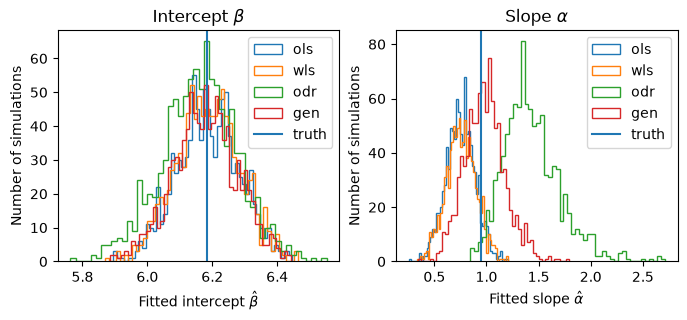

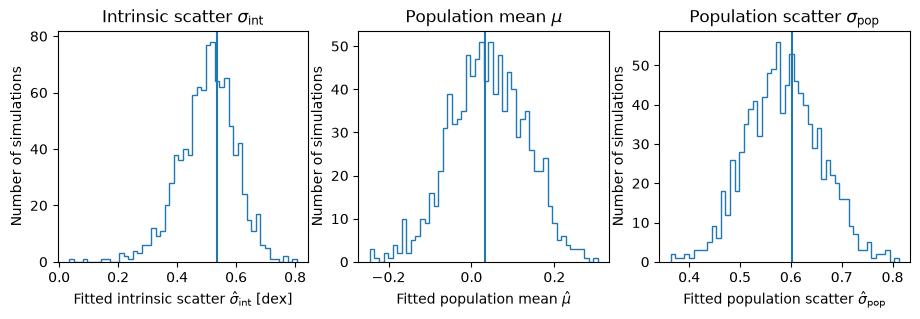

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

param = {'histtype':'step', 'bins':50}
ax[0].hist(fits_ols[:,0], **param, label='ols')
ax[0].hist(fits_wls[:,0], **param, label='wls')
ax[0].hist(fits_odr[:,0], **param, label='odr')
ax[0].hist(fits_gen[:,0], **param, label='gen')
ax[0].axvline(beta_true, label='truth')
ax[1].hist(fits_ols[:,2], **param, label='ols')
ax[1].hist(fits_wls[:,2], **param, label='wls')
ax[1].hist(fits_odr[:,2], **param, label='odr')
ax[1].hist(fits_gen[:,2], **param, label='gen')
ax[1].axvline(alpha_true, label='truth')
ax[0].legend();ax[1].legend()
ax[1].set_xlabel(r'Fitted slope $\hat{\alpha}$')
ax[1].set_ylabel('Number of simulations')
ax[1].set_title(r'Slope $\alpha$')
ax[0].set_xlabel(r'Fitted intercept $\hat{\beta}$')
ax[0].set_ylabel('Number of simulations')
ax[0].set_title(r'Intercept $\beta$')

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].hist(fits_gen[:,4], **param)
ax[0].axvline(sig_int)
ax[0].set_xlabel(r'Fitted intrinsic scatter $\hat{\sigma}_{\rm int}$ [dex]')
ax[0].set_ylabel('Number of simulations')
ax[0].set_title(r'Intrinsic scatter $\sigma_{\rm int}$')
ax[1].hist(fits_gen[:,6], **param)
ax[1].axvline(mu)
ax[1].set_xlabel(r'Fitted population mean $\hat{\mu}$')
ax[1].set_ylabel('Number of simulations')
ax[1].set_title(r'Population mean $\mu$')
ax[2].hist(fits_gen[:,8], **param)
ax[2].axvline(sig_pop)
ax[2].set_xlabel(r'Fitted population scatter $\hat{\sigma}_{\rm pop}$')
ax[2].set_ylabel('Number of simulations')
ax[2].set_title(r'Population scatter $\sigma_{\rm pop}$')

In [137]:
for i, (label, truth) in enumerate(zip(
  ['beta', 'alpha', 'sig_int', 'mu', 'sig_pop'],
  [beta_true, alpha_true, sig_int, mu, sig_pop]
)):
  print(f'Generative fit param: {label}')
  print(f'\t median: \t{np.median(fits_gen[:,i*2]):.4f}')
  print(f'\t std: \t\t{np.std(fits_gen[:,i*2]):.4f}')
  captured = fits_gen[:,i*2+1] >= np.abs(fits_gen[:,i*2] - truth)
  fractionCaptured = (np.sum(captured)/Nsamples)
  print(f'\t coverage:\t{np.sum(captured)/Nsamples}', end=' ')
  print("(Looks fine)" if np.abs(fractionCaptured-0.68) <= .05 else "")

for label, fits in zip(['ols', 'wls', 'odr', 'gen'],
                        [fits_ols, fits_wls, fits_odr, fits_gen]):
  captured = fits[:,3] >= np.abs(fits[:,2] - alpha_true)
  fractionCaptured = (np.sum(captured)/Nsamples)
  print(f"{label.upper()} fit:")
  print(f"\tFraction alpha_true recovered: {np.sum(captured)/Nsamples}", end=' ')
  print("(Looks fine)" if np.abs(fractionCaptured-0.68) <= .05 else "")

Generative fit param: beta
	 median: 	6.1786
	 std: 		0.0990
	 coverage:	0.651 (Looks fine)
Generative fit param: alpha
	 median: 	0.9773
	 std: 		0.1938
	 coverage:	0.675 (Looks fine)
Generative fit param: sig_int
	 median: 	0.5093
	 std: 		0.0938
	 coverage:	0.666 (Looks fine)
Generative fit param: mu
	 median: 	0.0384
	 std: 		0.0906
	 coverage:	0.671 (Looks fine)
Generative fit param: sig_pop
	 median: 	0.5838
	 std: 		0.0724
	 coverage:	0.642 (Looks fine)
OLS fit:
	Fraction alpha_true recovered: 0.317 
WLS fit:
	Fraction alpha_true recovered: 0.14 
ODR fit:
	Fraction alpha_true recovered: 0.091 
GEN fit:
	Fraction alpha_true recovered: 0.675 (Looks fine)


In [150]:
fits_error = np.zeros((5, Nsamples, 10))
Nsamples = 300
for i, errFactor in enumerate([.5, .75, 1, 1.25, 1.5]):
    fits_gen = np.zeros((Nsamples, 10))
    failed = np.zeros(Nsamples, dtype=bool)
    for j in range(Nsamples):
        rng = np.random.default_rng(j)

        # generate datasets !!

        #remember: generate ax + b instead of a(x-9.5)+b!!! 
        #earlier gen fit assumed so, so mu is going to be ~0, not ~9.5
        x_true = rng.normal(mu, sig_pop, N)
        y_true = alpha_true * (x_true) + beta_true + rng.normal(0, sig_int, N)
        #bootstrap da errorss
        idx = rng.choice(N, size=N, replace=True)
        xerr_sim = xerr[idx]
        yerr_sim = yerr[idx]
        x_obs = x_true + rng.normal(0, xerr_sim) 
        y_obs = y_true + rng.normal(0, yerr_sim)


        try:
            p_fit, cov_fit = gen(
                x_obs, y_obs,
                xerr_sim * errFactor,
                yerr_sim,
                alpha_hat_ols, mbh_hat_ols
            )
        except np.linalg.LinAlgError:
            failed[j] = True
            continue
        alpha_gen, beta_gen, sint_gen, mu_gen, spop_gen = p_fit
        sint_gen = np.exp(sint_gen)
        spop_gen = np.exp(spop_gen)
        alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))
        sint_sig_gen = sint_gen * sint_sig_gen
        spop_sig_gen = spop_gen * spop_sig_gen

        fits_gen[j] = [beta_gen, beta_sig_gen,
                    alpha_gen, alpha_sig_gen,
                    sint_gen, sint_sig_gen,
                    mu_gen, mu_sig_gen,
                    spop_gen, spop_sig_gen] 
    fits_error[i] = fits_gen
    print(
        f"errFactor={errFactor}: "
        f"{failed.sum()}/{Nsamples} fits had singular Hessians"
    )


errFactor=0.5: 0/300 fits had singular Hessians
errFactor=0.75: 0/300 fits had singular Hessians
errFactor=1: 0/300 fits had singular Hessians
errFactor=1.25: 7/300 fits had singular Hessians


/tmp/ipykernel_1494042/3075925310.py:36: RuntimeWarning: invalid value encountered in sqrt
  alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))


errFactor=1.5: 57/300 fits had singular Hessians


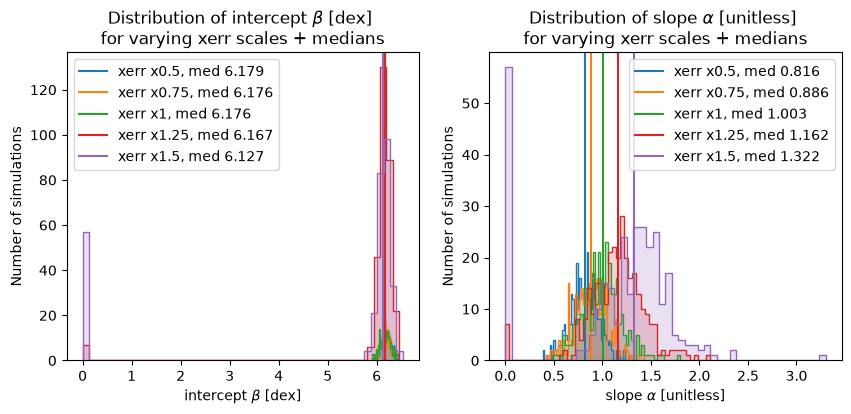

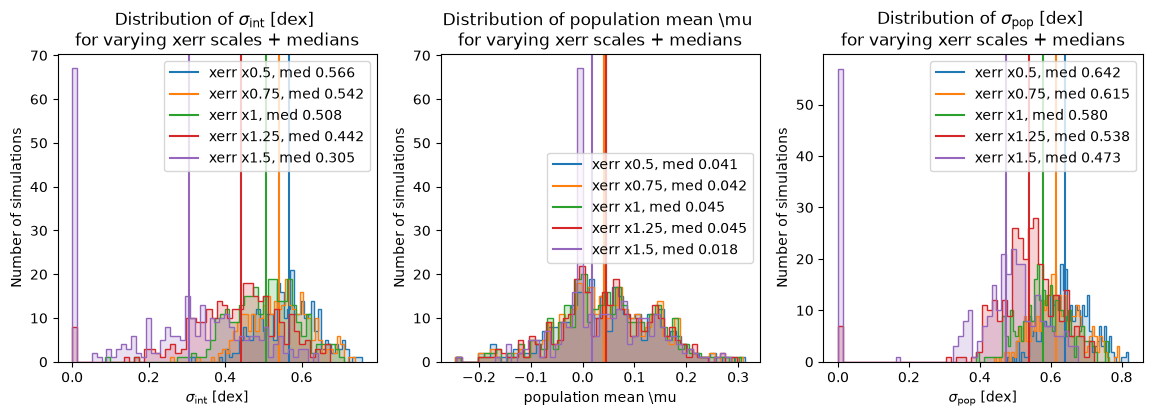

In [173]:
param = {'bins':50}
fix, ax = plt.subplots(1,2, figsize=(10, 4))
for j, label in enumerate([r'intercept $\beta$ [dex]', r'slope $\alpha$ [unitless]']):
    for i, (errFactor, _c) in enumerate(zip(
        [.5, .75, 1, 1.25, 1.5],
        ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    )):
        ax[j].hist(fits_error[i,:,j*2], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_error[i,:,j*2], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_error[i,:,j*2])
        ax[j].axvline(med, c=_c, label=f'xerr x{errFactor}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()
fix, ax = plt.subplots(1,3, figsize=(14, 4))
for j, label in enumerate([r'$\sigma_{\rm int}$ [dex]', r'population mean \mu', r'$\sigma_{\rm pop}$ [dex]']):
    for i, (errFactor, _c) in enumerate(zip(
        [.5, .75, 1, 1.25, 1.5],
        ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    )):
        ax[j].hist(fits_error[i,:,j*2+4], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_error[i,:,j*2+4], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_error[i,:,j*2+4])
        ax[j].axvline(med, c=_c, label=f'xerr x{errFactor}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()

In [202]:
fits_uniform_and_gaussian = np.zeros((2, Nsamples, 10))
flags = np.zeros(Nsamples, dtype=bool)
Nsamples = 300
errFactor = 0
for i in range(2):
    fits_gen = np.zeros((Nsamples, 10))
    failed = np.zeros(Nsamples, dtype=bool)
    for j in range(Nsamples):
        rng = np.random.default_rng(j)

        # generate datasets !!

        #remember: generate ax + b instead of a(x-9.5)+b!!! 
        #earlier gen fit assumed so, so mu is going to be ~0, not ~9.5
        if i == 0:
            x_true = rng.normal(mu, sig_pop, N)
        else:
            x_true = (rng.uniform()-.5)*2*sig_pop*np.sqrt(3) + mu
        y_true = alpha_true * (x_true) + beta_true + rng.normal(0, sig_int, N)
        #bootstrap da errorss
        idx = rng.choice(N, size=N, replace=True)
        xerr_sim = xerr[idx]
        yerr_sim = yerr[idx]
        x_obs = x_true + rng.normal(0, xerr_sim) 
        y_obs = y_true + rng.normal(0, yerr_sim)


        try:
            p_fit, cov_fit = gen(x_obs, y_obs, xerr_sim, yerr_sim, alpha_hat_ols, mbh_hat_ols)
        except np.linalg.LinAlgError:
            failed[j] = True
            continue
        alpha_gen, beta_gen, sint_gen, mu_gen, spop_gen = p_fit
        sint_gen = np.exp(sint_gen)
        spop_gen = np.exp(spop_gen)
        alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))
        sint_sig_gen = sint_gen * sint_sig_gen
        spop_sig_gen = spop_gen * spop_sig_gen

        fits_gen[j] = [beta_gen, beta_sig_gen,
                    alpha_gen, alpha_sig_gen,
                    sint_gen, sint_sig_gen,
                    mu_gen, mu_sig_gen,
                    spop_gen, spop_sig_gen] 
        flags[j] = ~failed[j]
    fits_uniform_and_gaussian[i] = fits_gen
    
    print(
        f"{failed.sum()}/{Nsamples} fits had singular Hessians"
    )


0/300 fits had singular Hessians


/tmp/ipykernel_1494042/3354373212.py:36: RuntimeWarning: invalid value encountered in sqrt
  alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))


89/300 fits had singular Hessians


In [204]:
flags.shape

(300,)

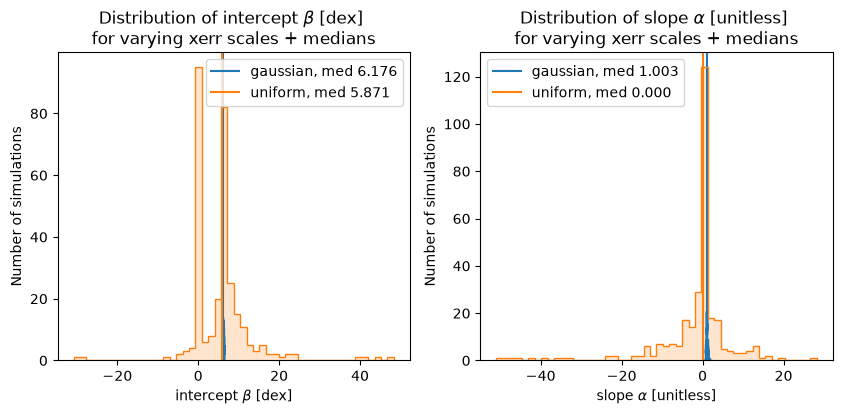

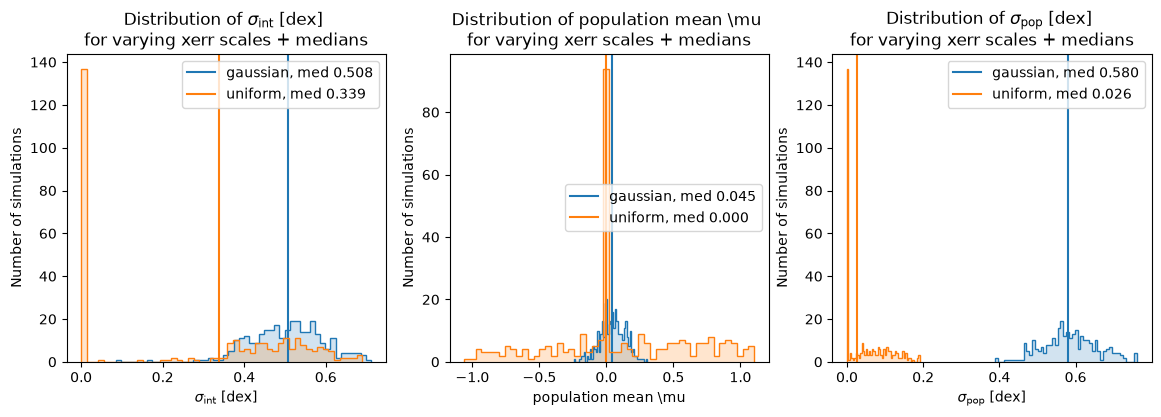

In [205]:
param = {'bins':50}
fix, ax = plt.subplots(1,2, figsize=(10, 4))
for j, label in enumerate([r'intercept $\beta$ [dex]', r'slope $\alpha$ [unitless]']):
    for i, (typeError, _c) in enumerate(zip(
        ['gaussian', 'uniform'],
        ['tab:blue', 'tab:orange']
    )):
        ax[j].hist(fits_uniform_and_gaussian[i,flags,j*2], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_uniform_and_gaussian[i,flags,j*2], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_uniform_and_gaussian[i,flags,j*2])
        ax[j].axvline(med, c=_c, label=f'{typeError}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()
fix, ax = plt.subplots(1,3, figsize=(14, 4))
for j, label in enumerate([r'$\sigma_{\rm int}$ [dex]', r'population mean \mu', r'$\sigma_{\rm pop}$ [dex]']):
    for i, (typeError, _c) in enumerate(zip(
        ['gaussian', 'uniform'],
        ['tab:blue', 'tab:orange']
    )):
        ax[j].hist(fits_uniform_and_gaussian[i,flags,j*2+4], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_uniform_and_gaussian[i,flags,j*2+4], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_uniform_and_gaussian[i,flags,j*2+4])
        ax[j].axvline(med, c=_c, label=f'{typeError}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()

In [213]:
fits_sint = np.zeros((2, Nsamples, 10))
flags = np.zeros(Nsamples, dtype=bool)
Nsamples = 300
errFactor = 0
for i in range(2):
    fits_gen = np.zeros((Nsamples, 10))
    failed = np.zeros(Nsamples, dtype=bool)
    for j in range(Nsamples):
        rng = np.random.default_rng(j)

        x_true = rng.normal(mu, sig_pop, N)
        if i == 0:
            y_true = alpha_true * (x_true) + beta_true + rng.normal(0, sig_int, N)
        else:
            y_true = alpha_true * (x_true) + beta_true
        #bootstrap da errorss
        idx = rng.choice(N, size=N, replace=True)
        xerr_sim = xerr[idx]
        yerr_sim = yerr[idx]
        x_obs = x_true + rng.normal(0, xerr_sim) 
        y_obs = y_true + rng.normal(0, yerr_sim)


        try:
            p_fit, cov_fit = gen(x_obs, y_obs, xerr_sim, yerr_sim, alpha_hat_ols, mbh_hat_ols)
        except np.linalg.LinAlgError:
            failed[j] = True
            continue
        alpha_gen, beta_gen, sint_gen, mu_gen, spop_gen = p_fit
        sint_gen = np.exp(sint_gen)
        spop_gen = np.exp(spop_gen)
        alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))
        sint_sig_gen = sint_gen * sint_sig_gen
        spop_sig_gen = spop_gen * spop_sig_gen

        fits_gen[j] = [beta_gen, beta_sig_gen,
                    alpha_gen, alpha_sig_gen,
                    sint_gen, sint_sig_gen,
                    mu_gen, mu_sig_gen,
                    spop_gen, spop_sig_gen]
    fits_sint[i] = fits_gen
    
    print(
        f"{failed.sum()}/{Nsamples} fits had singular Hessians"
    )


97/300 fits had singular Hessians


/tmp/ipykernel_1494042/785833721.py:32: RuntimeWarning: invalid value encountered in sqrt
  alpha_sig_gen, beta_sig_gen, sint_sig_gen, mu_sig_gen, spop_sig_gen = np.sqrt(np.diag(cov_fit))


178/300 fits had singular Hessians


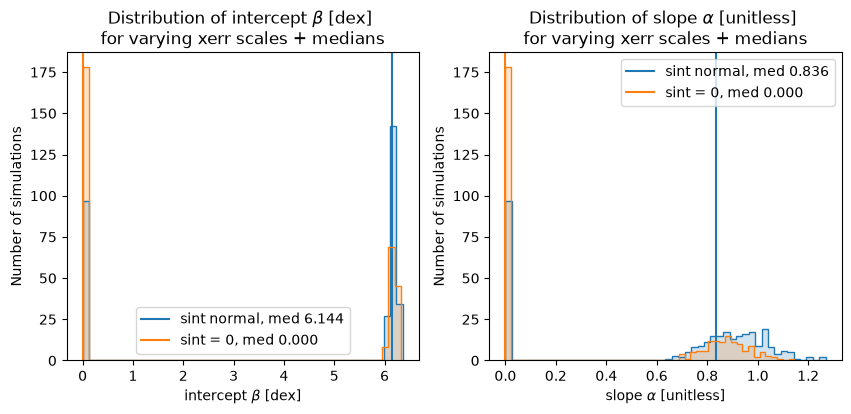

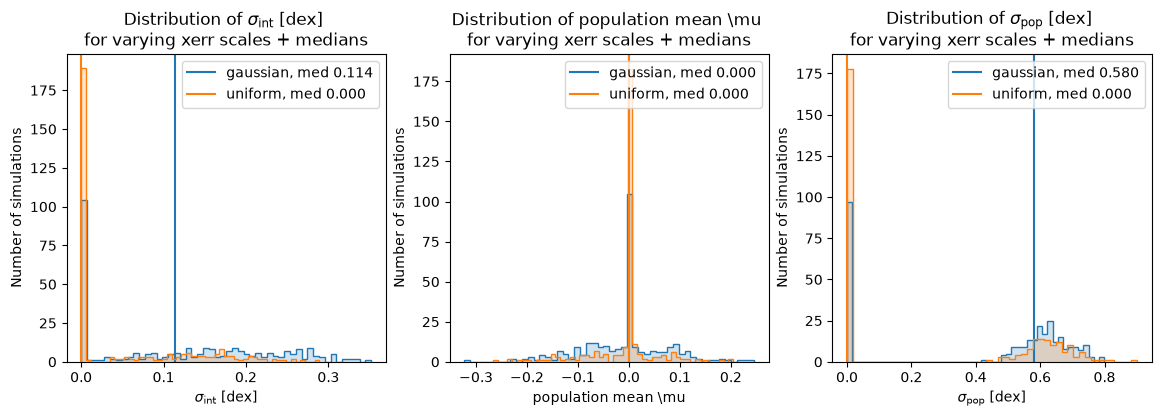

In [217]:
param = {'bins':50}
fix, ax = plt.subplots(1,2, figsize=(10, 4))
for j, label in enumerate([r'intercept $\beta$ [dex]', r'slope $\alpha$ [unitless]']):
    for i, (typeError, _c) in enumerate(zip(
        ['sint normal', 'sint = 0'],
        ['tab:blue', 'tab:orange']
    )):
        ax[j].hist(fits_sint[i,:,j*2], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_sint[i,:,j*2], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_sint[i,:,j*2])
        ax[j].axvline(med, c=_c, label=f'{typeError}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()
fix, ax = plt.subplots(1,3, figsize=(14, 4))
for j, label in enumerate([r'$\sigma_{\rm int}$ [dex]', r'population mean \mu', r'$\sigma_{\rm pop}$ [dex]']):
    for i, (typeError, _c) in enumerate(zip(
        ['gaussian', 'uniform'],
        ['tab:blue', 'tab:orange']
    )):
        ax[j].hist(fits_sint[i,:,j*2+4], **param, facecolor=_c, alpha=.2)
        ax[j].hist(fits_sint[i,:,j*2+4], **param, edgecolor=_c, histtype='step')
        med = np.median(fits_sint[i,:,j*2+4])
        ax[j].axvline(med, c=_c, label=f'{typeError}, med {med:.3f}')
    ax[j].set_title('Distribution of '+label+' \nfor varying xerr scales + medians')
    ax[j].set_xlabel(label)
    ax[j].set_ylabel('Number of simulations')
    ax[j].legend()

 I'll also try generating populations with uniform distirbution instead of gaussian with same mean/variance, gen fit will probably fail since its assuming that the scatter is gaussian but i can see to what degree will the fitted param change & how much this matters. 
 
 I'll also try generating populations where sigma_int = 0, and seeing how fitted param change, gen fit might fail to guess its 0.

**WHAT THE CHECKS FOUND:**

1. closure: I found out that the generative model is able to recover the true values i set within ~68% of the time, which is pretty good for closure
2. bias efficiency: i found that the model with the least bias in finding the slope was the generative model, the odr was biased high (due to assuming no intinsic scatter) and ols/wls was biased low (due to attenuation bias).
3. coverage:  generative model is pretty good at recovering the slope alpha, intercept beta, sig_int, mu, and sig_pop within 68%. other models do much worse at recovering slope
4. a) by varying xerrors from .5-1.5x original xerrors, i found out that a larger xerr corresponds to a higher estimated slope. the population & intrinsic scatter was estimated to be lower as xerr increased, also. for alpha/mu, varying xerror didn't change anything that much

    b) by changing uniform/gaussian populations of population error, i saw many singular hessians :|. I saw that the generative model becomes very bad at estimating intercept, slope, intrinsic scatter, and population mean (gigantic spread in fitted values), and straight up did not find any population scatter. i think it was interesting it fitted an almost normal distribution of population means - makes sense, given we generated data based off a normal distribution. 

    c) by changing intrisic error to 0, i saw that there was a lot more singular hessians & failures to fit the data at all. I also saw that the slope is biased a little lower than if i kept sigma_intrinsic, but not by very much. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

i asked chatgpt with help plotting, figuring out how to flag out singular hessians when they came up so i didn't plot them, and also some errors in my code when i was trying to figure out how to adapt the class's ols/wls/odr/genereative fit into my notebook